In [3]:
import pyLDAvis
from gensim.models import ldaseqmodel
from topic_models import corpus
ldaseq = ldaseqmodel.LdaSeqModel.load("models/ldaseq15_new.model")

vis_data = {}

# TODO
# get average topic weight in documents over timeslice
# multiply topic-term occurence by weight in timeslice to get more relevant data

#for t in range(0,ldaseq.num_time_slices,1):
#    doc_topics,topic_term,doc_lengths,term_frequency,vocab = ldaseq.dtm_vis(time=t,corpus=corpus)
#    vis_data[f"ts_{t}"] = {}
#    vis_data[f"ts_{t}"]["doc_topics"] = doc_topics
#    vis_data[f"ts_{t}"]["topic_term"] = topic_term
##    vis_data[f"ts_{t}"]["doc_lengths"] = doc_lengths
 #   vis_data[f"ts_{t}"]["term_frequency"] = term_frequency
 #   vis_data[f"ts_{t}"]["vocab"] = vocab

#doc_topics,topic_term,doc_lengths,term_frequency,vocab = ldaseq.dtm_vis(time=0,corpus=corpus)

#tm_data = pyLDAvis.prepare(doc_topic_dists=doc_topics,doc_lengths=doc_lengths,vocab=vocab,term_frequency=term_frequency,topic_term_dists=topic_term)


Parsing protocols: 100%|██████████| 214/214 [01:04<00:00,  3.30it/s]


Finished protocol preprocessing
GENERATING LDASEQ DATASET


Preparing LDASEQ data: 100%|██████████| 214/214 [00:00<00:00, 790.88it/s]
2026-04-29 15:06:37,275 : INFO : loading LdaSeqModel object from models/ldaseq15_new.model
2026-04-29 15:06:37,470 : INFO : loading id2word recursively from models/ldaseq15_new.model.id2word.* with mmap=None
2026-04-29 15:06:37,470 : INFO : LdaSeqModel lifecycle event {'fname': 'models/ldaseq15_new.model', 'datetime': '2026-04-29T15:06:37.470764', 'gensim': '4.3.3', 'python': '3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]', 'platform': 'Linux-6.19.9-zabbly+-x86_64-with-glibc2.36', 'event': 'loaded'}


array([[<Axes: title={'center': '0'}>, <Axes: title={'center': '1'}>,
        <Axes: title={'center': '2'}>],
       [<Axes: title={'center': '3'}>, <Axes: title={'center': '4'}>,
        <Axes: title={'center': '5'}>],
       [<Axes: title={'center': '6'}>, <Axes: title={'center': '7'}>,
        <Axes: title={'center': '8'}>],
       [<Axes: title={'center': '9'}>, <Axes: title={'center': '10'}>,
        <Axes: title={'center': '11'}>],
       [<Axes: title={'center': '12'}>, <Axes: title={'center': '13'}>,
        <Axes: title={'center': '14'}>]], dtype=object)

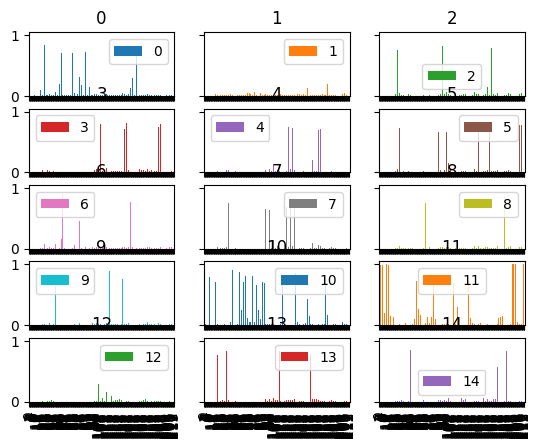

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
from topic_models import visualize_topic_distribution_over_time

#df = visualize_topic_distribution_over_time(ldaseq)
data = []
for i in range(214):
    data.append(ldaseq.doc_topics(i))
df = pd.DataFrame(data=data)
df.plot(kind="bar",subplots=True,layout=(5,3),sharey=True)

In [ ]:
t_0_vals = []

for i in range(9):
    doc_topics = ldaseq.doc_topics(i)
    t_0_vals.append(doc_topics[11])

t_0_avg = sum(t_0_vals) / 9

print(t_0_avg)

#ldaseq.print_topic(11)

0.8974959648627119


[('bevölkerung', 0.002723698358887619),
 ('anzuordnen', 0.0024235445187445063),
 ('austausch', 0.0019391307379354472),
 ('bündnis', 0.00193260725418719),
 ('ansatz', 0.001766924820520953),
 ('schluss', 0.0017410821611282374),
 ('abzuwenden', 0.0016861910013787735),
 ('reden', 0.0016816784130479425),
 ('politik', 0.0016666055067793863),
 ('ähnlich', 0.0016592005881110286),
 ('antworten', 0.0014256950011962532),
 ('angebote', 0.0011476510447902947),
 ('fiskus', 0.0011348432023443376),
 ('mindestens', 0.0011275092717461276),
 ('anreize', 0.0011250952241316627),
 ('abgrund', 0.0010932506061129158),
 ('ausstieg', 0.0010726722515641514),
 ('arbeit', 0.0010545837229620383),
 ('landwirtschaft', 0.001054549850542312),
 ('treffen', 0.001041321700314509)]

In [6]:
for i in range(10):
    doc_topics = ldaseq.doc_topics(i)
    print(doc_topics[10])

6.3085512412074575e-06
0.08745362476154073
0.01265275847864709
5.440252427712647e-06
3.494670627293378e-05
0.0024610459703046407
5.019702331651734e-06
0.0002515973193434924
0.7940457825997095
2.7830733480882443e-06


Text(0.5, 1.0, 'Themengewichte - LDA')

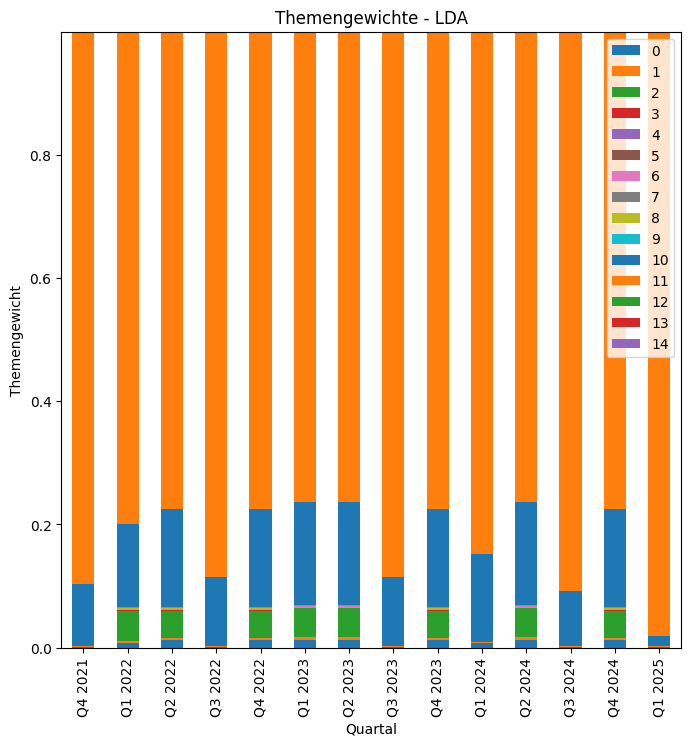

In [43]:
doc_slices = [9, 17, 19, 13, 19, 18, 18, 13, 19, 16, 18, 10, 19, 6]
import numpy as np

df_avg = pd.DataFrame(0,index=[i for i in range(14)],columns=[i for i in range(15)],dtype=float)

for ts, i in enumerate(doc_slices):
    j = 0
    topics_data = {}
    cum_topic_weights = np.zeros(15)
    for doc in range(j,i):
        topic_weights = ldaseq.doc_topics(doc)
        
        for ti in range(15):
            topic_weight = topic_weights[ti]
            cum_topic_weights[ti] += topic_weight
    cum_topic_weights = cum_topic_weights / i
    df_avg.loc[ts] = cum_topic_weights
    j = j + i

df_avg

df_avg.plot(
    kind="bar",
    subplots=False,
    stacked=True,
    #layout=(5,3),
    figsize=(8,8)
    )

plt.xticks(df_avg.index,["Q4 2021","Q1 2022","Q2 2022","Q3 2022","Q4 2022","Q1 2023","Q2 2023","Q3 2023","Q4 2023","Q1 2024","Q2 2024","Q3 2024","Q4 2024","Q1 2025"],rotation=90)
plt.xlabel("Quartal")
plt.ylabel("Themengewicht")
plt.title("Themengewichte - LDA")


In [4]:
from itertools import combinations
def calculate_coherence(w2v_model,term_rankings):
    overall_coherence = 0.0
    for topic_index in range(len(term_rankings)):
        # check each pair of terms
        pair_scores = []
        for pair in combinations( term_rankings[topic_index], 2 ):
            try:
                #print(pair[0],pair[1])
                similarity = w2v_model.wv.similarity(pair[0],pair[1])
            except KeyError:
                similarity = 0
            pair_scores.append( similarity )
        # get the mean for all pairs in this topic
        topic_score = sum(pair_scores) / len(pair_scores)
        overall_coherence += topic_score
    # get the mean score across all topics
    return overall_coherence / len(term_rankings)

In [33]:

from gensim.models import Word2Vec

w2v_model = Word2Vec.load("models/w2v_model.bin")
ldaseq = ldaseqmodel.LdaSeqModel.load("models/ldaseq15_new.model")

def get_coherence_lda(ldaseq: ldaseqmodel.LdaSeqModel):
    n_components = ldaseq.num_topics
    term_rankings = []
    for topic_index in range(n_components):
        term_rankings.append([t for t,p in ldaseq.print_topic(topic_index,time=0,top_terms=10)])
    return calculate_coherence(w2v_model,term_rankings)

print(get_coherence_lda(ldaseq))


2026-04-15 15:00:24,375 : INFO : loading Word2Vec object from models/w2v_model.bin
2026-04-15 15:00:24,382 : INFO : loading wv recursively from models/w2v_model.bin.wv.* with mmap=None
2026-04-15 15:00:24,382 : INFO : loading vectors from models/w2v_model.bin.wv.vectors.npy with mmap=None
2026-04-15 15:00:24,392 : INFO : loading syn1neg from models/w2v_model.bin.syn1neg.npy with mmap=None
2026-04-15 15:00:24,401 : INFO : setting ignored attribute cum_table to None
2026-04-15 15:00:24,498 : INFO : Word2Vec lifecycle event {'fname': 'models/w2v_model.bin', 'datetime': '2026-04-15T15:00:24.498531', 'gensim': '4.3.3', 'python': '3.11.2 (main, Apr 28 2025, 14:11:48) [GCC 12.2.0]', 'platform': 'Linux-6.19.9-zabbly+-x86_64-with-glibc2.36', 'event': 'loaded'}
2026-04-15 15:00:24,500 : INFO : loading LdaSeqModel object from models/ldaseq15_new.model
2026-04-15 15:00:24,612 : INFO : loading id2word recursively from models/ldaseq15_new.model.id2word.* with mmap=None
2026-04-15 15:00:24,612 : INFO

0.3680786216148623


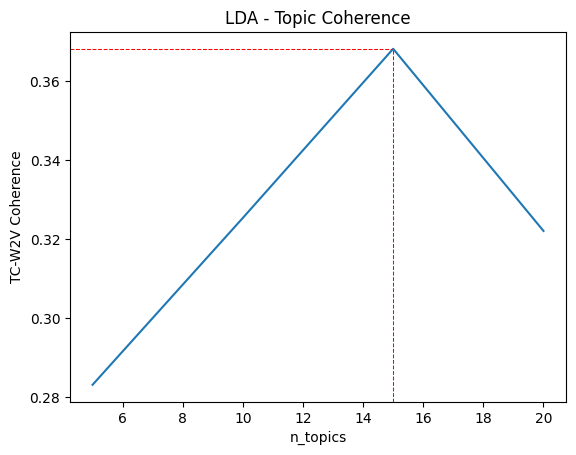

In [118]:
k_values = [5,10,15,20]
coherences = [0.28303359515137144,0.3252794359955522,0.3680786216148623,0.32197336853378344]

plt.plot(k_values,coherences)
plt.title("LDA - Topic Coherence")
plt.xlabel("n_topics")
plt.ylabel("TC-W2V Coherence")
plt.axhline(coherences[2],xmax=0.65,color="red",linestyle="--",lw=0.75)
plt.axvline(k_values[2],ymax=0.95,color="red",linestyle="--",lw=0.75)

In [46]:
ldaseq.print_topic(11)

[('bevölkerung', 0.002723698358887619),
 ('anzuordnen', 0.0024235445187445063),
 ('austausch', 0.0019391307379354472),
 ('bündnis', 0.00193260725418719),
 ('ansatz', 0.001766924820520953),
 ('schluss', 0.0017410821611282374),
 ('abzuwenden', 0.0016861910013787735),
 ('reden', 0.0016816784130479425),
 ('politik', 0.0016666055067793863),
 ('ähnlich', 0.0016592005881110286),
 ('antworten', 0.0014256950011962532),
 ('angebote', 0.0011476510447902947),
 ('fiskus', 0.0011348432023443376),
 ('mindestens', 0.0011275092717461276),
 ('anreize', 0.0011250952241316627),
 ('abgrund', 0.0010932506061129158),
 ('ausstieg', 0.0010726722515641514),
 ('arbeit', 0.0010545837229620383),
 ('landwirtschaft', 0.001054549850542312),
 ('treffen', 0.001041321700314509)]

      0     1     2     3    4    5     6    7    8     9     10    11   12  \
0   0.00  0.00  0.05  0.00  0.0  0.0  0.00  0.0  0.0  0.10  0.05  0.05  0.0   
1   0.00  0.00  0.05  0.00  0.0  0.0  0.00  0.0  0.0  0.10  0.05  0.05  0.0   
2   0.00  0.00  0.05  0.00  0.0  0.0  0.00  0.0  0.0  0.10  0.05  0.05  0.0   
3   0.00  0.00  0.05  0.00  0.0  0.0  0.00  0.0  0.0  0.10  0.00  0.05  0.0   
4   0.00  0.00  0.05  0.00  0.0  0.0  0.00  0.0  0.0  0.05  0.00  0.05  0.0   
5   0.05  0.05  0.00  0.00  0.0  0.0  0.00  0.0  0.0  0.05  0.00  0.05  0.0   
6   0.00  0.10  0.00  0.00  0.0  0.0  0.00  0.0  0.0  0.05  0.00  0.05  0.0   
7   0.00  0.10  0.00  0.00  0.0  0.0  0.00  0.0  0.0  0.05  0.05  0.05  0.0   
8   0.00  0.10  0.00  0.00  0.0  0.0  0.00  0.0  0.0  0.05  0.05  0.05  0.0   
9   0.00  0.10  0.00  0.00  0.0  0.0  0.00  0.0  0.0  0.05  0.05  0.05  0.0   
10  0.00  0.10  0.00  0.00  0.0  0.0  0.00  0.0  0.0  0.05  0.05  0.05  0.0   
11  0.00  0.10  0.00  0.05  0.0  0.0  0.00  0.0  0.0

array([[<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >]], dtype=object)

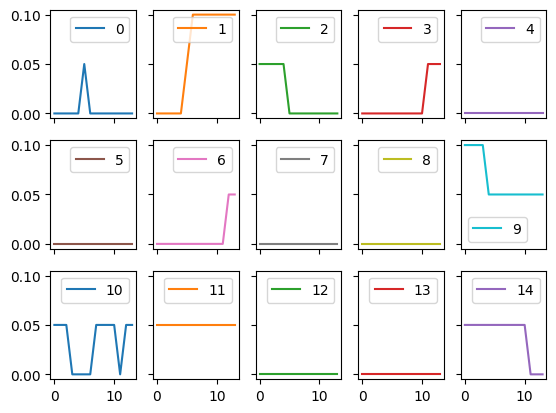

In [54]:

#ldaseq = ldaseqmodel.LdaSeqModel.load("models/ldaseq15_new.model")

from sec_terms_2 import sec_terms_2


import pandas as pd
df = pd.DataFrame()
for i in range(ldaseq.num_time_slices):
    c = 0
    for ti in range(ldaseq.num_topics):
            desc = [w for w,p in ldaseq.print_topic(time=i,topic=ti)]
            for t in desc:
                if t in sec_terms_2:
                    c += 1
            df.loc[i,ti] = c
            c = 0
#print(df)
#df["si_sum"] = df.astype(bool).sum(axis=1)
#df["pct_sec"] = df.drop(["sec_sum"],axis=1).sum(axis=1) / 15
import matplotlib.pyplot as plt
#df.index = ["Q4 2021","Q1 2022","Q2 2022","Q3 2022","Q4 2022","Q1 2023","Q2 2023","Q3 2023","Q4 2023","Q1 2024","Q2 2024","Q3 2024","Q4 2024","Q1 2025"]
#df = df.drop("si_sum",axis=1) / 15
#df.plot(subplots=True,layout=(5,3),sharey=True,title="Themen - LDA",rot=90,figsize=(20,15),sharex=True)


#plt.plot(df.index,df["si_sum"],label="LDA")
#plt.plot(df.index,[0.45, 2.1, 1.15, 0.7, 1.2, 1.5, 1.25, 0.7, 1.2, 1.2, 1.25, 1.0, 1.4, 0.9],label="NMF")
#plt.xticks(df.index,["Q4 2021","Q1 2022","Q2 2022","Q3 2022","Q4 2022","Q1 2023","Q2 2023","Q3 2023","Q4 2023","Q1 2024","Q2 2024","Q3 2024","Q4 2024","Q1 2025"],rotation=90)
#plt.xlabel("Quartal")
#plt.ylabel("SI / n_topics")
#plt.title("SI pro Thema - Vergleich")
#plt.legend()

#for row in df.index:
#    print(row,df.iloc[row].tolist())
df_sr = df / 20
df_weighed = df * df_avg
print(df_sr)
df_sr.plot(subplots=True,layout=(3,5),sharey=True)


#df_weighed



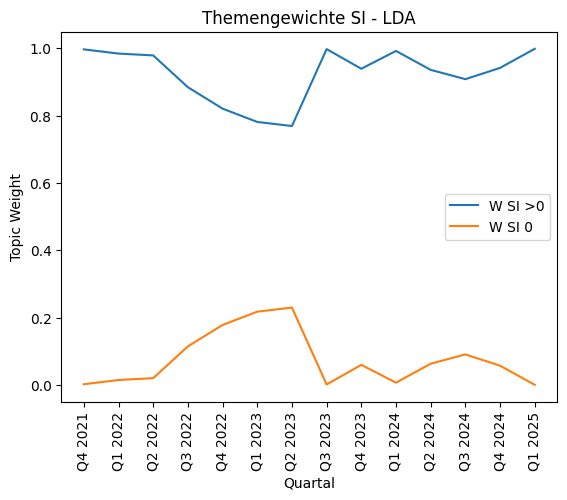

In [44]:
df_weighed["si_weights_total"] = df_avg[df.astype(bool) == True].sum(axis=1)
df_weighed["no_si_weights_total"] = df_avg[df.astype(bool) == False].sum(axis=1)

plt.plot(df_weighed.index,df_weighed["si_weights_total"],label="W SI >0")

plt.plot(df_weighed.index,df_weighed["no_si_weights_total"],label="W SI 0")

plt.xticks(df.index,["Q4 2021","Q1 2022","Q2 2022","Q3 2022","Q4 2022","Q1 2023","Q2 2023","Q3 2023","Q4 2023","Q1 2024","Q2 2024","Q3 2024","Q4 2024","Q1 2025"],rotation=90)
plt.xlabel("Quartal")
plt.ylabel("Topic Weight")
plt.title("Themengewichte SI - LDA")
plt.legend()

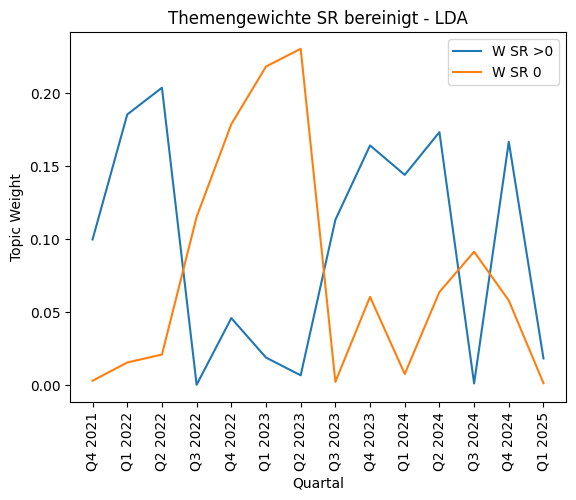

In [ ]:
df_weighed["si_weights_total"] = df_avg[df.astype(bool) == True].drop(11,axis=1).sum(axis=1)
df_weighed["no_si_weights_total"] = df_avg[df.astype(bool) == False].drop(11,axis=1).sum(axis=1)

plt.plot(df_weighed.index,df_weighed["si_weights_total"],label="∑(W) SR >0")

plt.plot(df_weighed.index,df_weighed["no_si_weights_total"],label="∑(W) SR 0")

plt.xticks(df.index,["Q4 2021","Q1 2022","Q2 2022","Q3 2022","Q4 2022","Q1 2023","Q2 2023","Q3 2023","Q4 2023","Q1 2024","Q2 2024","Q3 2024","Q4 2024","Q1 2025"],rotation=90)
plt.xlabel("Quartal")
plt.ylabel("Topic Weight")
plt.title("Themengewichte SR bereinigt - LDA")
plt.legend()

([<matplotlib.axis.XTick at 0x7f0527d91150>,
 [Text(0.0, 0, 'Q4 2021'),
  Text(1.0, 0, 'Q1 2022'),
  Text(2.0, 0, 'Q2 2022'),
  Text(3.0, 0, 'Q3 2022'),
  Text(4.0, 0, 'Q4 2022'),
  Text(5.0, 0, 'Q1 2023'),
  Text(6.0, 0, 'Q2 2023'),
  Text(7.0, 0, 'Q3 2023'),
  Text(8.0, 0, 'Q4 2023'),
  Text(9.0, 0, 'Q1 2024'),
  Text(10.0, 0, 'Q2 2024'),
  Text(11.0, 0, 'Q3 2024'),
  Text(12.0, 0, 'Q4 2024'),
  Text(13.0, 0, 'Q1 2025')])

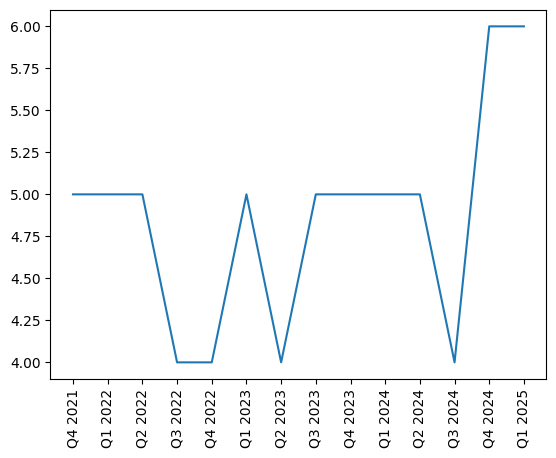

In [18]:
plt.plot(df.index,df["si_sum"])
plt.xticks(df.index,rotation=90)

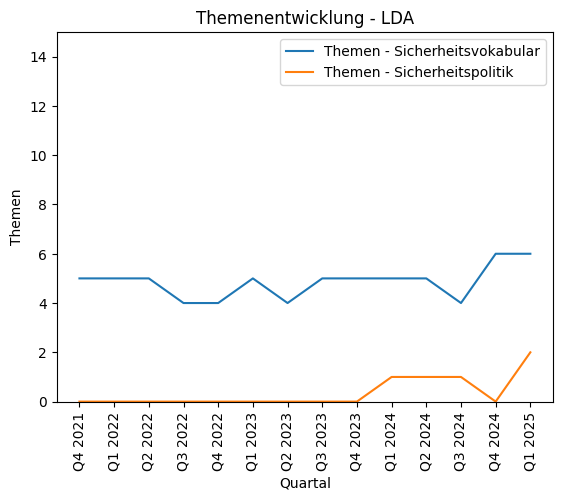

In [153]:
plt.plot(df.index,df["si_sum"],label="Themen - Sicherheitsvokabular")
plt.plot(df.index,[0,0,0,0,0,0,0,0,0,1,1,1,0,2],label="Themen - Sicherheitspolitik")
plt.xticks(df.index,["Q4 2021","Q1 2022","Q2 2022","Q3 2022","Q4 2022","Q1 2023","Q2 2023","Q3 2023","Q4 2023","Q1 2024","Q2 2024","Q3 2024","Q4 2024","Q1 2025"],rotation=90)
plt.ylabel("Themen")
plt.ylim(0,15)
plt.xlabel("Quartal")
plt.title("Themenentwicklung - LDA")
plt.legend()

In [ ]:
pyLDAvis.display(tm_data)


|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Bündnis (?)| 0|
|2| Bevölkerung (Corona?)|0|
|3| Ostdeutschland|0|
|4| Geringverdiener|0|
|5| Arbeitsmarkt|0|
|6| Corona | 0|
|7| Klima | 0|
|8| Impfstoffversorgung |0|
|9| Gesetzespacket Hygienekonzepte|0
|10| Verbrechen Duisburg | 0|
|11| Impfungen | 0|
|12| Kindergrundsicherung | 0|
|13| Sanktionsregieme | 0|
|14| Energie (Erdgas) |0|
|15| Energei (Kohle) |0|

In [66]:
tm_1_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_1"]["doc_topics"],doc_lengths=vis_data["ts_1"]["doc_lengths"],vocab=vis_data["ts_1"]["vocab"],term_frequency=vis_data["ts_1"]["term_frequency"],topic_term_dists=vis_data["ts_1"]["topic_term"])
pyLDAvis.display(tm_1_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Finanzen| 0|
|2| Parlamentarische Abläufe |0|
|3| Flucht/Migration |0|
|4| Geringverdiener|0|
|5| Arbeitsmarkt|0|
|6| Corona | 0|
|7| Klima (-gipfel Glasgow) | 0|
|8| Impfstoffversorgung |0|
|9| Gesetzespacket Hygienekonzepte|0
|10| Verbrechen Duisburg | 0|
|11| Impfungen | 0|
|12| Kindergrundsicherung | 0|
|13| Sanktionsregieme | 0|
|14| Energie (Erdgas) |0|
|15| Energie (Kohle) |0|

In [67]:
tm_2_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_2"]["doc_topics"],doc_lengths=vis_data["ts_2"]["doc_lengths"],vocab=vis_data["ts_2"]["vocab"],term_frequency=vis_data["ts_2"]["term_frequency"],topic_term_dists=vis_data["ts_2"]["topic_term"])
pyLDAvis.display(tm_2_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Demokratie (Volksvertretung)| 0|
|2| Kohleausstieg |0|
|3| Flucht/Migration |0|
|4| Geringverdiener|0|
|5| Arbeitsmarkt|0|
|6| Coronamaßnahmen | 0|
|7| Klima | 0|
|8| Impfstoffversorgung |0|
|9| Gesetzespacket Hygienekonzepte|0
|10| Verbrechen Duisburg | 0|
|11| Impfungen/Impfpflicht | 0|
|12| Kindergrundsicherung | 0|
|13| Sanktionsregieme | 0|
|14| Energie (Erdgas) |0|
|15| Energie (Kohle) |0|

In [68]:
tm_3_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_3"]["doc_topics"],doc_lengths=vis_data["ts_3"]["doc_lengths"],vocab=vis_data["ts_3"]["vocab"],term_frequency=vis_data["ts_3"]["term_frequency"],topic_term_dists=vis_data["ts_3"]["topic_term"])
pyLDAvis.display(tm_3_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Bürgerinnen / Demokratie | 0|
|2| Kohleausstieg |0|
|3| Migration/Ostdeutschland |0|
|4| Geringverdiener|0|
|5| Finanzpolitik |0|
|6| Corona | 0|
|7| Klima | 0|
|8| Impfstoffversorgung |0|
|9| Gesetzespacket Hygienekonzepte|0
|10| Verbrechen Duisburg | 0|
|11| Impfungen | 0|
|12| Kindergrundsicherung | 0|
|13| Sanktionsregieme/Bürgergeld | 0|
|14| Energie (Erdgas) |0|
|15| Energie (Kohle) |0|

In [69]:
tm_4_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_4"]["doc_topics"],doc_lengths=vis_data["ts_4"]["doc_lengths"],vocab=vis_data["ts_4"]["vocab"],term_frequency=vis_data["ts_4"]["term_frequency"],topic_term_dists=vis_data["ts_4"]["topic_term"])
pyLDAvis.display(tm_4_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Demokratie | 0|
|2| Kohleausstieg |0|
|3| Migration |0|
|4| Corona Wirtschaftsfolgen |0|
|5| Arbeitsmarkt|0|
|6| Corona | 0|
|7| Klima | 0|
|8| Impfstoffversorgung |0|
|9| Gesetzespacket Hygienekonzepte|0
|10| Verbrechen Duisburg | 0|
|11| Impfungen/Impfpflicht | 0|
|12| Kindergrundsicherung | 0|
|13| Sanktionsregieme/Sozialleistungen | 0|
|14| Energie (Erdgas) |0|
|15| Energie (Kohle) |0|

In [70]:
tm_5_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_5"]["doc_topics"],doc_lengths=vis_data["ts_5"]["doc_lengths"],vocab=vis_data["ts_5"]["vocab"],term_frequency=vis_data["ts_5"]["term_frequency"],topic_term_dists=vis_data["ts_5"]["topic_term"])
pyLDAvis.display(tm_5_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Demokratie/Energieversorgung | 0|
|2| Kraftverkehr ? |0|
|3| Bürgerräte |0|
|4| Sozialleistungen |0|
|5| Klima |0|
|6| Corona | 0|
|7| Klimagesetzgebung | 0|
|8| Klimakrise |0|
|9| Gesetzespacket Hygienekonzepte|0
|10| Verbrechen | 0|
|11| Impfungen | 0|
|12| Erwartungsmanagement ? | 0|
|13| Sanktionsregieme | 0|
|14| Energie (Erdgas) |0|
|15| Energie (Kohle) |0|

In [71]:
tm_6_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_6"]["doc_topics"],doc_lengths=vis_data["ts_6"]["doc_lengths"],vocab=vis_data["ts_6"]["vocab"],term_frequency=vis_data["ts_6"]["term_frequency"],topic_term_dists=vis_data["ts_6"]["topic_term"])
pyLDAvis.display(tm_6_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Blackout| 0|
|2| Kraftfahrzeug |0|
|3| Bürgerräte |0|
|4| Finanzen |0|
|5| Wirtschaft |0|
|6| Demokratie (verteidigen?) | 0|
|7| Europa | 0|
|8| Klima/Energieversorgung |0|
|9| Gesetzespacket Hygienekonzepte|0
|10| Verbrechen | 0|
|11| Impfungen | 0|
|12| Wirtschaftl. Folgen Corona | 0|
|13| Sanktionsregieme/Sozialleistungen | 0|
|14| Energie (Erdgas) |0|
|15| Energiepolitik |0|

In [58]:
tm_7_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_7"]["doc_topics"],doc_lengths=vis_data["ts_7"]["doc_lengths"],vocab=vis_data["ts_7"]["vocab"],term_frequency=vis_data["ts_7"]["term_frequency"],topic_term_dists=vis_data["ts_7"]["topic_term"])
pyLDAvis.display(tm_7_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Blackout | 0|
|2| Außenpolitik|0|
|3| Steuer |0|
|4| Migration |0|
|5| Bürgergeld/Sozialleistungen |0|
|6| Energiewende | 0|
|7| Europa | 0|
|8| Klimakrise |0|
|9| Grenzpolitik |0
|10| Verbrechen | 0|
|11| Impfpflicht | 0|
|12| Impfungen | 0|
|13| Sanktionsregieme | 0|
|14| Energie (Erdgas) / Länderöffnungsklausel |0|
|15| Klimakonferenz / Corona-Folgen |0|

In [72]:
tm_8_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_8"]["doc_topics"],doc_lengths=vis_data["ts_8"]["doc_lengths"],vocab=vis_data["ts_8"]["vocab"],term_frequency=vis_data["ts_8"]["term_frequency"],topic_term_dists=vis_data["ts_8"]["topic_term"])
pyLDAvis.display(tm_8_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Blackout| 0|
|2| Grenzpolitik |0|
|3| Steuer (Durschnittssteuersatz) |0|
|4| Bundesverfassungsgericht |0|
|5| Gesundheitsversorgung |0|
|6| Digitalpolitik | 0|
|7| Grundgesetz | 0|
|8| Klimakrise |0|
|9| Kraftfahrzeuge ?|0
|10| Klimakonferenzen | 0|
|11| Impfungen / Impfstatus | 0|
|12| Impfungen / Impfpflicht | 0|
|13| Sanktionsregieme | 0|
|14| Energie (Erdgas) / Länderöffnungsklausel |0|
|15| Klimakonferenzen |0|

In [73]:
tm_9_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_9"]["doc_topics"],doc_lengths=vis_data["ts_9"]["doc_lengths"],vocab=vis_data["ts_9"]["vocab"],term_frequency=vis_data["ts_9"]["term_frequency"],topic_term_dists=vis_data["ts_9"]["topic_term"])
pyLDAvis.display(tm_9_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Verfassungsänderung ?| 0|
|2| Energiepolitik|0|
|3| Parlamentsabläufe |0|
|4| Finanzen |0|
|5| Gesundheitspolitik |0|
|6| Hybride Kriegsführung (Digital) | 1|
|7| Grundgesetz | 0|
|8| Klimakrise |0|
|9| Automobil |0
|10| Klimapolitik | 0|
|11| Corona (infizieren) | 0|
|12| Impfpflicht | 0|
|13| Sanktionsregieme | 0|
|14| Länderöffnungsklausel |0|
|15| Klimakonferenzen |0|

In [74]:
tm_10_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_10"]["doc_topics"],doc_lengths=vis_data["ts_10"]["doc_lengths"],vocab=vis_data["ts_10"]["vocab"],term_frequency=vis_data["ts_10"]["term_frequency"],topic_term_dists=vis_data["ts_10"]["topic_term"])
pyLDAvis.display(tm_10_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Verfassungsänderung | 0|
|2| Atomenergie |0|
|3| Steuer ?|0|
|4| Finanzen |0|
|5| Gesundheit |0|
|6| Corona (Boosterimpfungen) | 0|
|7| Grundgesetz | 0|
|8| Hybride Kriegsführung |1|
|9| Autos / PKWs|0
|10| Klimapolitik | 0|
|11| Impfungen (Impfstatus) | 0|
|12| Einkommen | 0|
|13| Sanktionsregieme | 0|
|14| Länderöffnungsklausel |0|
|15| Klimakonferenzen |0|

In [75]:
tm_11_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_11"]["doc_topics"],doc_lengths=vis_data["ts_11"]["doc_lengths"],vocab=vis_data["ts_11"]["vocab"],term_frequency=vis_data["ts_11"]["term_frequency"],topic_term_dists=vis_data["ts_11"]["topic_term"])
pyLDAvis.display(tm_11_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Demokratie| 0|
|2| Arbeitnehmer|0|
|3| Corona |0|
|4| Letzte Generation ?|0|
|5| Gesundheit / Steuer ?|0|
|6| Digitales | 0|
|7| Grundgesetz | 0|
|8| Covid?/Kriegsführung? |1|
|9| Kraftfahrer ? |0
|10| Klima | 0|
|11| Impfprämie | 0|
|12| Einkommen/Mindestlohn | 0|
|13| Sanktionsregieme | 0|
|14| Länderöffnungsklausel |0|
|15| Klimakonferenzen |0|

In [76]:
tm_12_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_12"]["doc_topics"],doc_lengths=vis_data["ts_12"]["doc_lengths"],vocab=vis_data["ts_12"]["vocab"],term_frequency=vis_data["ts_12"]["term_frequency"],topic_term_dists=vis_data["ts_12"]["topic_term"])
pyLDAvis.display(tm_12_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Verfassungsänderung abgelehnt| 0|
|2| Regierungsverantwortung |0|
|3| CSU-Familienpolitik |0|
|4| Energiepolitik |0|
|5| Patriotismus |0|
|6| Impfungen | 0|
|7| Regierungsperformanz | 0|
|8| Covid/Kriegsführung |0|
|9| Autofahrer |0
|10| Debatten Klimakonferenzen | 0|
|11| Impfungen / Impfstatus | 0|
|12| Einkommen | 0|
|13| Sanktionsregieme | 0|
|14| Länderöffnungsklausel |0|
|15| Klimakonferenzen |0|

In [77]:
tm_13_data = pyLDAvis.prepare(doc_topic_dists=vis_data["ts_13"]["doc_topics"],doc_lengths=vis_data["ts_13"]["doc_lengths"],vocab=vis_data["ts_13"]["vocab"],term_frequency=vis_data["ts_13"]["term_frequency"],topic_term_dists=vis_data["ts_13"]["topic_term"])
pyLDAvis.display(tm_13_data)

|TOPIC|THEMA|Sicherheitspolitisch|
|-----|-----|--------------------|
|1| Verfassungsänderung abgelehnt | 0|
|2| Kernkraft |0|
|3| CSU Familienpolitik |0|
|4| Bundesverfassungsgericht / Letzte Generation |0|
|5| Durchschnittssatz / Patriotismus |0|
|6| Digital Abwehr | 1|
|7| Regierung Kollaps ? | 0|
|8| Hybride Kriegsführung ? |1|
|9| Autofahrer |0 |
|10| Debatten Klimakonferenzen | 0|
|11| Impfungen / Impfprämie | 0|
|12| Einkommen | 0|
|13| Sanktionsregieme | 0|
|14| Länderöffnungsklausel |0|
|15| Klimakonferenzen / Hospitalisierungsrate |0|

In [33]:
for i,j in enumerate(vocab[:20]):
    print(j,term_frequency[i])

abartig 592.0
abbildet 499.0
abgegeben 494.0
abgegebene 522.0
abgeordnetenlobby 461.0
absenken 481.0
absenkung 515.0
absicht 516.0
abstandsgebot 561.0
abstimmung 512.0
absurd 589.0
abwahl 486.0
abzustimmen 525.0
afd 587.0
all 597.0
allein 594.0
allerdings 657.0
alterspräsident 645.0
alterspräsidenten 707.0
amt 558.0


In [44]:
tt = ldaseq.print_topic_times(topic=0)
ldaseq.doc_topics()
ldaseq.num_time_slices
ldaseq.print_topics(time=0)
#print(tt)
for i,t in enumerate(tt):
    print(i)
    for w,p in t:
        print("\t",w)

TypeError: LdaSeqModel.doc_topics() missing 1 required positional argument: 'doc_number'

In [43]:
from rich.console import Console
from rich.table import Table

console = Console()
table = Table()

table.add_column("Timeslice")

for t in range(0,10):
    #print("TOPIC ",t)
    table.add_column(f"Topic {t}")
    for timeslice, topic in enumerate(ldaseq.print_topic_times(topic=t)):
        #print(f"\tTS:{timeslice}")
        table.add_row(str(t),str([w[0] for w in topic]))
        